# 📩 Email Spam Detection

## Technologies Used
- Seaborn
- Matplotlib
- Pandas
- NumPy
- WordCloud
- NLTK
- Scikit-learn
- XGBoost
- CountVectorizer
- TF-IDF

### 🧰 1. Import Libraries

In [13]:
import numpy as np
import pandas as pd

### 📂 2. Load Dataset

In [14]:
data = pd.read_csv("spam.csv", encoding="latin-1")
data.head()
data.shape
data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

### 🧹 3. Data Cleaning

In [15]:
data.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1,inplace=True)

data=data.rename(columns={"v1":"target","v2":"text"})

### 🔢 4. Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['target']=encoder.fit_transform(data['target'])

### 🔁 5. Remove Duplicates

In [17]:
data.duplicated().sum()

data=data.drop_duplicates(keep='first')
data.shape

(5169, 2)

### ✏️ 6. Feature Engineering (Text Length Features)

In [18]:
data['num_chars']=data['text'].apply(len)

### 📚 7. NLP Setup (NLTK)

In [19]:
import nltk
nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 🔤 8. Word & Sentence Count

In [20]:
data['num_words']=data['text'].apply(lambda x:len(nltk.word_tokenize(x)))
data['num_sentence']=data['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

### 📊 9. EDA – Distribution Analysis

In [21]:
data[data['target']==0]['num_chars']

0       111
1        29
3        49
4        61
6        77
       ... 
5565     12
5568     37
5569     57
5570    125
5571     26
Name: num_chars, Length: 4516, dtype: int64

<Axes: xlabel='num_chars', ylabel='Count'>

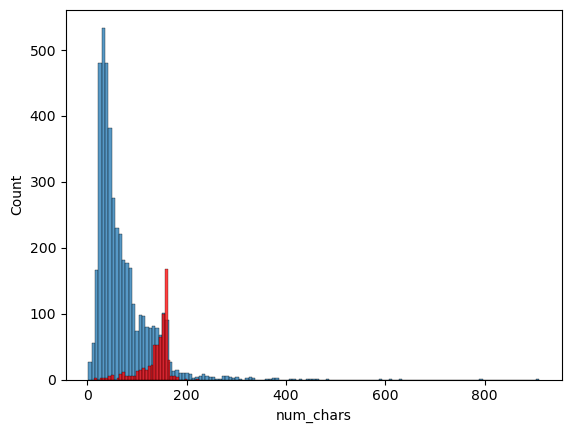

In [22]:
import seaborn as sns

sns.histplot(data[data['target']==0]['num_chars'])
sns.histplot(data[data['target']==1]['num_chars'],color='r')

### 📈 10. Statistical Summary

In [23]:
data[data['target']==1][['num_chars','num_words','num_sentence']].describe()

,num_chars,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### 🔗 11. Pairplot & Correlation

<Axes: >

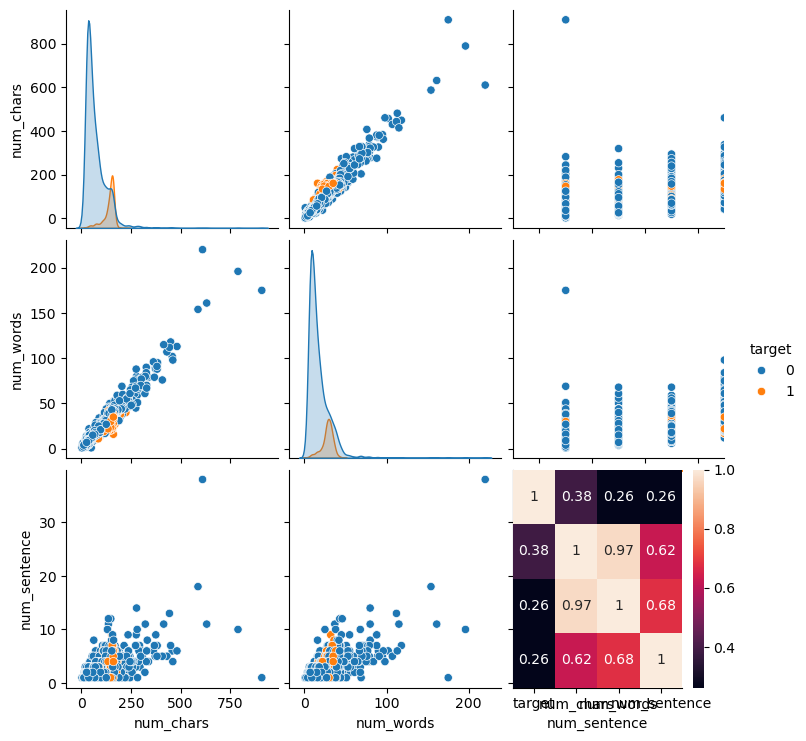

In [24]:
sns.pairplot(data,hue="target")

sns.heatmap(data[["target","num_chars","num_words","num_sentence"]].corr(),annot=True)

### 🔡 12. Text Preprocessing

#### 🔽 Lowercase

In [25]:
data['text']=data['text'].apply(lambda x:x.lower())

#### ✂️ Tokenization

In [26]:
data['text']=data['text'].apply(lambda x:nltk.word_tokenize(x))

#### 🌱 Stemming

In [27]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
data['text']=data['text'].apply(lambda x:[ps.stem(y) for y in x])

#### 🚫 Remove Stopwords

In [28]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords=stopwords.words('english')

data['text']=data['text'].apply(lambda x:[y for y in x if y not in stopwords])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### 🔤 Keep Only Alphabets

In [29]:
data['text']=data['text'].apply(lambda x:[y for y in x if y.isalpha()])

#### 🔗 Join Back Text

In [30]:
data['text']=data['text'].apply(lambda x:" ".join(x))

### 13. ☁️ WordCloud Visualization

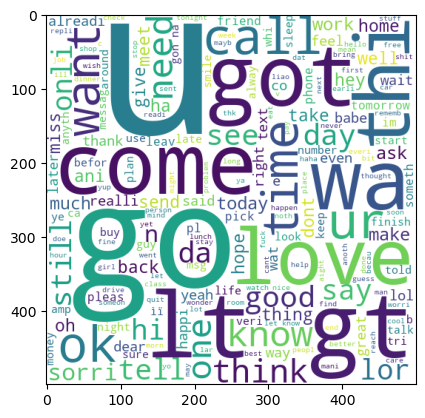

In [31]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

spam_wc=wc.generate(data[data['target']==1]['text'].str.cat(sep=" "))
ham_wc=wc.generate(data[data['target']==0]['text'].str.cat(sep=" "))

import matplotlib.pyplot as plt
plt.imshow(spam_wc)
plt.imshow(ham_wc)

### 14. 🔥 Most Frequent Words (Spam)

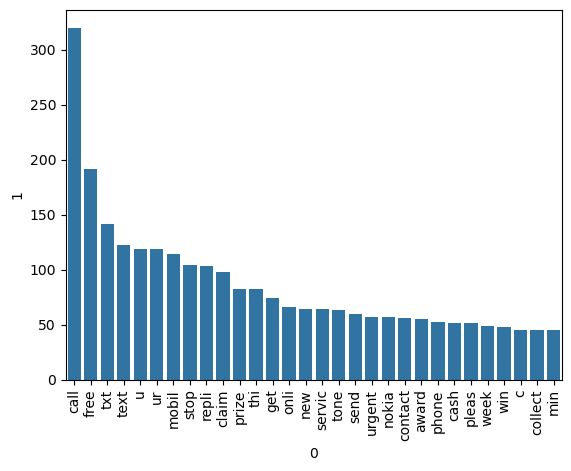

In [32]:
spam_corpus=[]
for msg in data[data['target']==1]['text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

### 15. 🧊 Most Frequent Words (Ham)

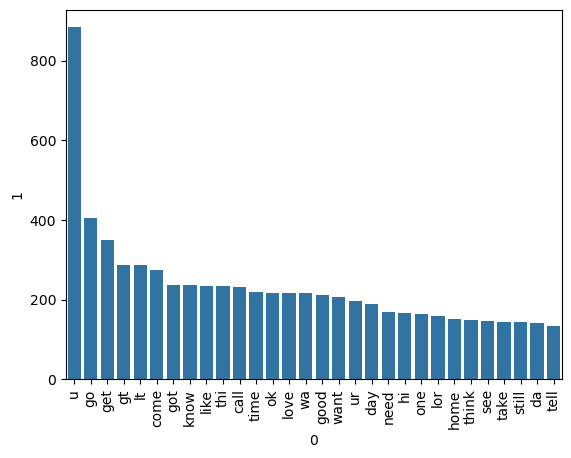

In [33]:
ham_corpus=[]
for msg in data[data['target']==0]['text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

### 🔢 16. Text Vectorization

In [34]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

cv=CountVectorizer()
tfidf=TfidfVectorizer()

X=tfidf.fit_transform(data['text']).toarray()
X.shape

y=data['target']

### ✂️ 17. Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

### 🤖 18. Naive Bayes Models

In [36]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

#### 🔹 GaussianNB

In [37]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[792 104]
 [ 31 107]]
0.5071090047393365


#### 🔹 MultinomialNB

In [38]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9574468085106383
[[896   0]
 [ 44  94]]
1.0


#### 🔹 BernoulliNB

In [39]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.965183752417795
[[888   8]
 [ 28 110]]
0.9322033898305084


### 🧠 19. Multiple Classifier Comparison

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

### 📊 20. Train & Evaluate All Models

In [41]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'Adaboost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}

def train_classifier(clf,X_train,X_test,y_train,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

accuracy_scores=[]
precision_scores=[]
for name,clf in clfs.items():
    cur_acc,cur_pre=train_classifier(clf,X_train,X_test,y_train,y_test)
    print("For ",name)
    print("Accuracy: ",cur_acc)
    print("Precision: ",cur_pre)

    accuracy_scores.append(cur_acc)
    precision_scores.append(cur_pre)

For  SVC
Accuracy:  0.9709864603481625
Precision:  0.9736842105263158
For  KN
Accuracy:  0.9090909090909091
Precision:  1.0
For  NB
Accuracy:  0.9574468085106383
Precision:  1.0
For  DT
Accuracy:  0.9313346228239845
Precision:  0.8252427184466019
For  LR
Accuracy:  0.9535783365570599
Precision:  0.95
For  RF
Accuracy:  0.9729206963249516
Precision:  0.9910714285714286
For  Adaboost
Accuracy:  0.9206963249516441
Precision:  0.8181818181818182
For  BgC
Accuracy:  0.9535783365570599
Precision:  0.8571428571428571
For  ETC
Accuracy:  0.9758220502901354
Precision:  0.9829059829059829
For  GBDT
Accuracy:  0.9497098646034816
Precision:  0.9387755102040817
For  xgb
Accuracy:  0.9680851063829787
Precision:  0.9646017699115044


### 🏁 21. Final Performance Table

In [42]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores})

In [43]:
performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.970986,0.973684
1,KN,0.909091,1.000000
2,NB,0.957447,1.000000
3,DT,0.931335,0.825243
4,LR,0.953578,0.950000
5,RF,0.972921,0.991071
6,Adaboost,0.920696,0.818182
7,BgC,0.953578,0.857143
8,ETC,0.975822,0.982906
9,GBDT,0.949710,0.938776


In [46]:
import joblib

joblib.dump(rfc, "fake_email_model.pkl")
joblib.dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']